In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np

# 드라이브 마운트
drive.mount('/content/drive')

# 1. 파일이 저장된 정확한 경로 (본인의 경로에 맞게 수정하세요)
base_path = '/content/drive/MyDrive/ColabNotebooks/'

Mounted at /content/drive


In [ ]:
nutrition_cohort = pd.read_csv(f'{base_path}nutrition_cohort.csv')

등록된 폰트 이름: NanumGothic


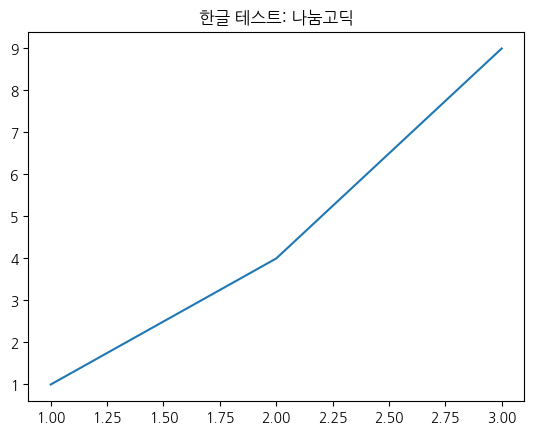

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Colab)
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc

font_path = '/content/drive/MyDrive/ColabNotebooks/NanumGothic-Regular.ttf'

# 1️⃣ matplotlib font manager에 폰트 등록
font_manager.fontManager.addfont(font_path)

# 2️⃣ 폰트 이름 가져오기
font_name = font_manager.FontProperties(fname=font_path).get_name()
print("등록된 폰트 이름:", font_name)

# 3️⃣ 전역 설정
rc('font', family=font_name)
rc('axes', unicode_minus=False)

# 4️⃣ 테스트
plt.figure()
plt.title("한글 테스트: 나눔고딕")
plt.plot([1, 2, 3], [1, 4, 9])
plt.show()




In [ ]:
# ============================================================================
# 1. 기본 정보
# ============================================================================
print("\n📌 1. 데이터 기본 정보")
print("-"*80)
print(f"총 환자 수: {nutrition_cohort['SUBJECT_ID'].nunique():,}명")
print(f"총 입원 수: {nutrition_cohort['HADM_ID'].nunique():,}건")
print(f"데이터 형태: {nutrition_cohort.shape}")
print(f"\n컬럼 수: {len(nutrition_cohort.columns)}개")

print("\n📋 컬럼 목록:")
print(nutrition_cohort.columns.tolist())


📌 1. 데이터 기본 정보
--------------------------------------------------------------------------------
총 환자 수: 75,339명
총 입원 수: 188,646건
데이터 형태: (188771, 23)

컬럼 수: 23개

📋 컬럼 목록:
['SUBJECT_ID', 'HADM_ID', 'AGE', 'ALBUMIN', 'HEMOGLOBIN', 'MCV', 'CALCIUM', 'PHOSPHATE', 'MAGNESIUM', 'POTASSIUM', 'LYMPHOCYTE', 'TOTAL_PROTEIN', 'DIABETES', 'CKD', 'CKD_STAGE', 'OSTEOPOROSIS', 'HYPERTENSION', 'HEART_FAILURE', 'DEMENTIA', 'STROKE', 'COPD', 'CANCER', 'COMORBIDITY_COUNT']



📌 2. 데이터 타입 및 결측치 분석
--------------------------------------------------------------------------------
                  Data_Type  Missing_Count  Missing_Percent  Unique_Values
TOTAL_PROTEIN       float64         186430            98.76             42
CKD_STAGE           float64         173130            91.71              6
ALBUMIN             float64         139611            73.96             51
LYMPHOCYTE          float64         131197            69.50            996
PHOSPHATE           float64          46075            24.41             71
CALCIUM             float64          44978            23.83            100
MAGNESIUM           float64          41541            22.01             44
MCV                 float64          32197            17.06             79
HEMOGLOBIN          float64          31194            16.52            165
POTASSIUM           float64          28560            15.13             53
AGE                   int64              0             0.00             

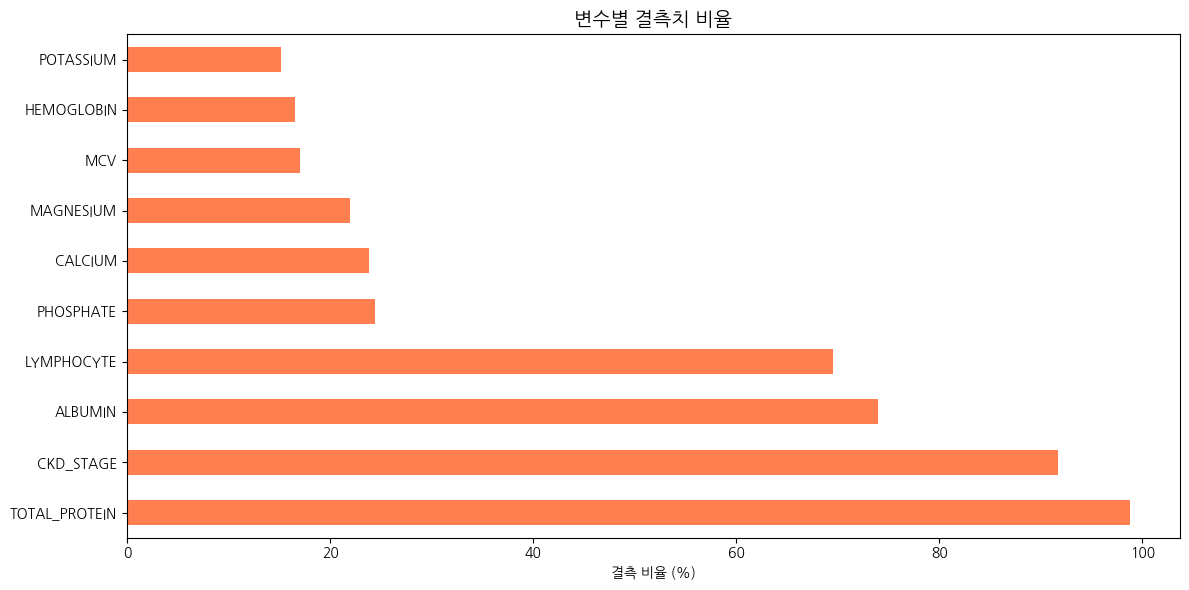

In [ ]:

# ============================================================================
# 2. 데이터 타입 및 결측치
# ============================================================================
print("\n📌 2. 데이터 타입 및 결측치 분석")
print("-"*80)

missing_summary = pd.DataFrame({
    'Data_Type': nutrition_cohort.dtypes,
    'Missing_Count': nutrition_cohort.isnull().sum(),
    'Missing_Percent': (nutrition_cohort.isnull().sum() / len(nutrition_cohort) * 100).round(2),
    'Unique_Values': nutrition_cohort.nunique()
})
missing_summary = missing_summary.sort_values('Missing_Percent', ascending=False)
print(missing_summary)

# 결측치 시각화
plt.figure(figsize=(12, 6))
missing_pct = (nutrition_cohort.isnull().sum() / len(nutrition_cohort) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]  # 결측치가 있는 것만
if len(missing_pct) > 0:
    missing_pct.plot(kind='barh', color='coral')
    plt.xlabel('결측 비율 (%)')
    plt.title('변수별 결측치 비율', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("결측치가 없습니다!")


📌 3. 인구통계학적 특성
--------------------------------------------------------------------------------

연령 통계:
count    188771.000000
mean         76.875129
std           8.394360
min          60.000000
25%          70.000000
50%          76.000000
75%          83.000000
max         106.000000
Name: AGE, dtype: float64


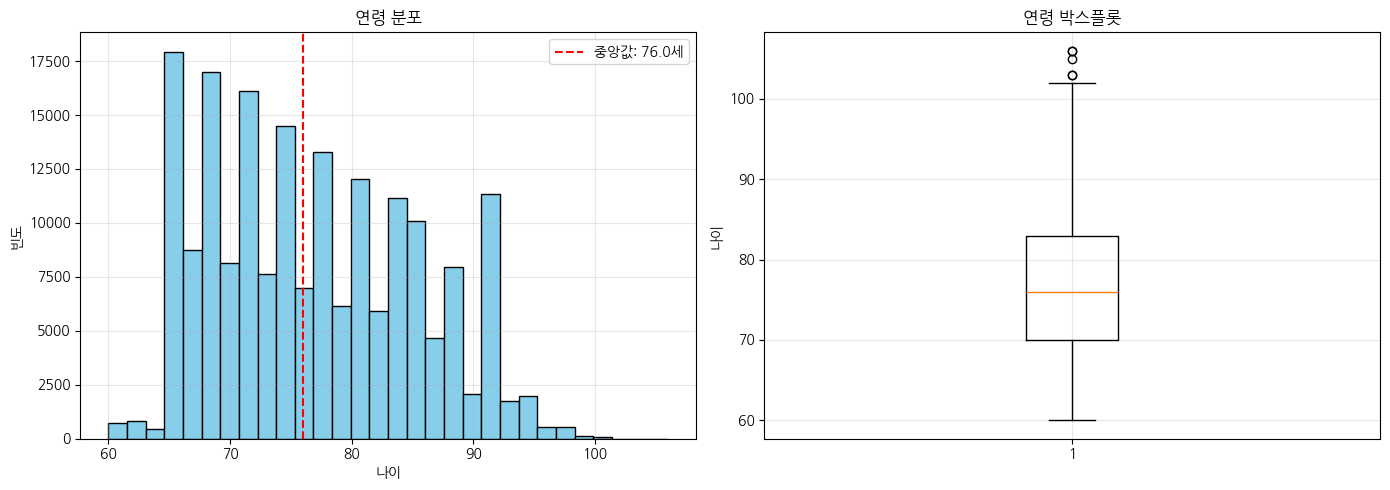


연령대별 분포:
AGE_GROUP
40세 미만         0
40-60세       327
60-80세    124297
80세 이상     64147
Name: count, dtype: int64


In [ ]:
# ============================================================================
# 3. 인구통계학적 특성
# ============================================================================
print("\n📌 3. 인구통계학적 특성")
print("-"*80)

# 나이 분포
print(f"\n연령 통계:")
print(nutrition_cohort['AGE'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 나이 히스토그램
axes[0].hist(nutrition_cohort['AGE'].dropna(), bins=30, color='skyblue', edgecolor='black')
axes[0].axvline(nutrition_cohort['AGE'].median(), color='red', linestyle='--',
                label=f'중앙값: {nutrition_cohort["AGE"].median():.1f}세')
axes[0].set_xlabel('나이')
axes[0].set_ylabel('빈도')
axes[0].set_title('연령 분포', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 나이 박스플롯
axes[1].boxplot(nutrition_cohort['AGE'].dropna(), vert=True)
axes[1].set_ylabel('나이')
axes[1].set_title('연령 박스플롯', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 연령대별 분포
nutrition_cohort['AGE_GROUP'] = pd.cut(nutrition_cohort['AGE'],
                                        bins=[0, 40, 60, 80, 120],
                                        labels=['40세 미만', '40-60세', '60-80세', '80세 이상'])
print("\n연령대별 분포:")
print(nutrition_cohort['AGE_GROUP'].value_counts().sort_index())


📌 4. 영양 관련 실험실 검사 수치
--------------------------------------------------------------------------------

영양 지표 기술통계:
        ALBUMIN  HEMOGLOBIN        MCV    CALCIUM  PHOSPHATE  MAGNESIUM  \
count  49160.00   157577.00  156574.00  143793.00  142696.00  147230.00   
mean       3.45       10.97      91.36       8.88       3.48       1.96   
std        0.62        2.16       7.00       0.65       0.83       0.29   
min        1.00        3.00      52.00       5.00       1.00       0.50   
25%        3.00        9.50      87.00       8.50       3.00       1.80   
50%        3.50       11.10      91.00       8.90       3.40       2.00   
75%        3.90       12.50      96.00       9.30       3.90       2.10   
max        6.00       20.00     120.00      15.00       8.00       4.90   

       POTASSIUM  
count  160211.00  
mean        4.16  
std         0.58  
min         2.00  
25%         3.80  
50%         4.10  
75%         4.50  
max         7.00  


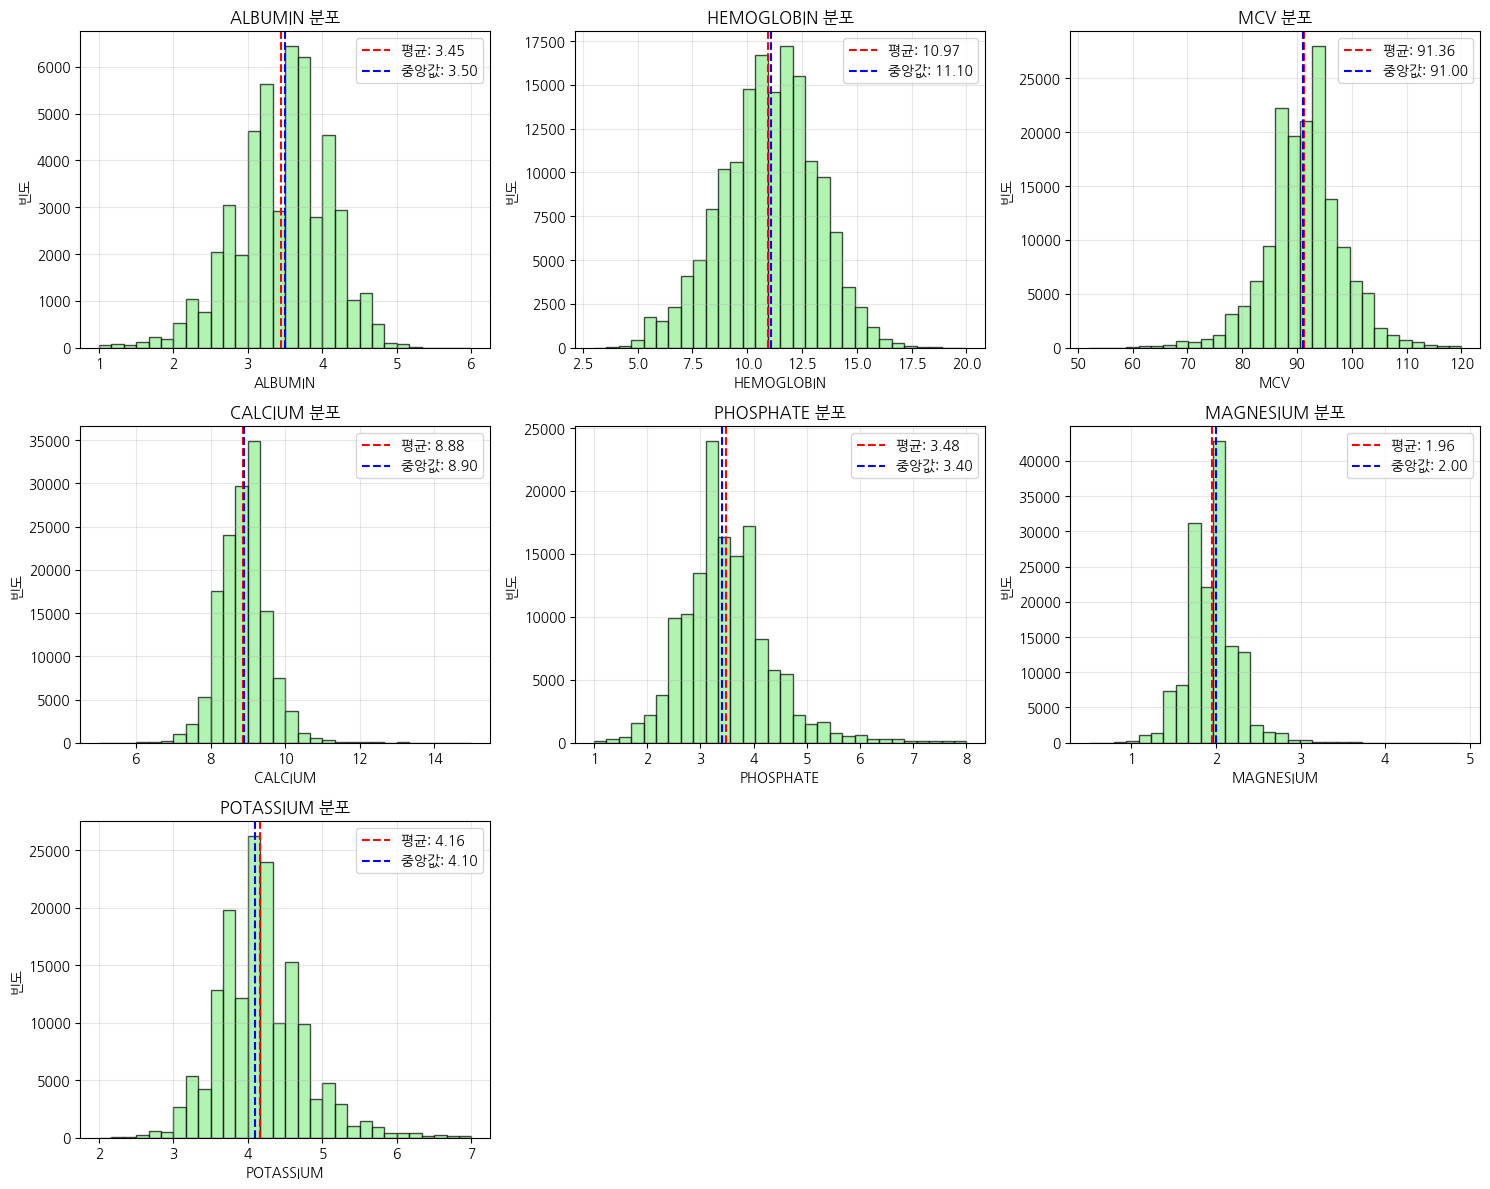

In [ ]:
# ============================================================================
# 4. 영양 관련 실험실 검사 수치 (Lab Values)
# ============================================================================
print("\n📌 4. 영양 관련 실험실 검사 수치")
print("-"*80)

lab_columns = ['ALBUMIN', 'HEMOGLOBIN', 'MCV', 'CALCIUM',
               'PHOSPHATE', 'MAGNESIUM', 'POTASSIUM'      ]

# 가용한 lab 컬럼만 선택
lab_columns = [col for col in lab_columns if col in nutrition_cohort.columns]

print("\n영양 지표 기술통계:")
print(nutrition_cohort[lab_columns].describe().round(2))

# Lab values 분포 시각화
n_labs = len(lab_columns)
n_cols = 3
n_rows = (n_labs + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*4))
axes = axes.flatten() if n_labs > 1 else [axes]

for idx, col in enumerate(lab_columns):
    if idx < len(axes):
        data = nutrition_cohort[col].dropna()

        axes[idx].hist(data, bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
        axes[idx].axvline(data.mean(), color='red', linestyle='--',
                         label=f'평균: {data.mean():.2f}')
        axes[idx].axvline(data.median(), color='blue', linestyle='--',
                         label=f'중앙값: {data.median():.2f}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('빈도')
        axes[idx].set_title(f'{col} 분포', fontweight='bold')
        axes[idx].legend()
        axes[idx].grid(alpha=0.3)

# 빈 subplot 제거
for idx in range(n_labs, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()



📌 5. 동반질환 분석
--------------------------------------------------------------------------------

동반질환 유병률:
                환자 수  유병률 (%)
HYPERTENSION   71940    38.11
CKD            24545    13.00
HEART_FAILURE  23665    12.54
CANCER         19572    10.37
COPD           11631     6.16
DEMENTIA        9025     4.78
OSTEOPOROSIS    7139     3.78
STROKE          3017     1.60

평균 동반질환 수: 1.07개
동반질환 없는 환자: 101677명 (53.9%)


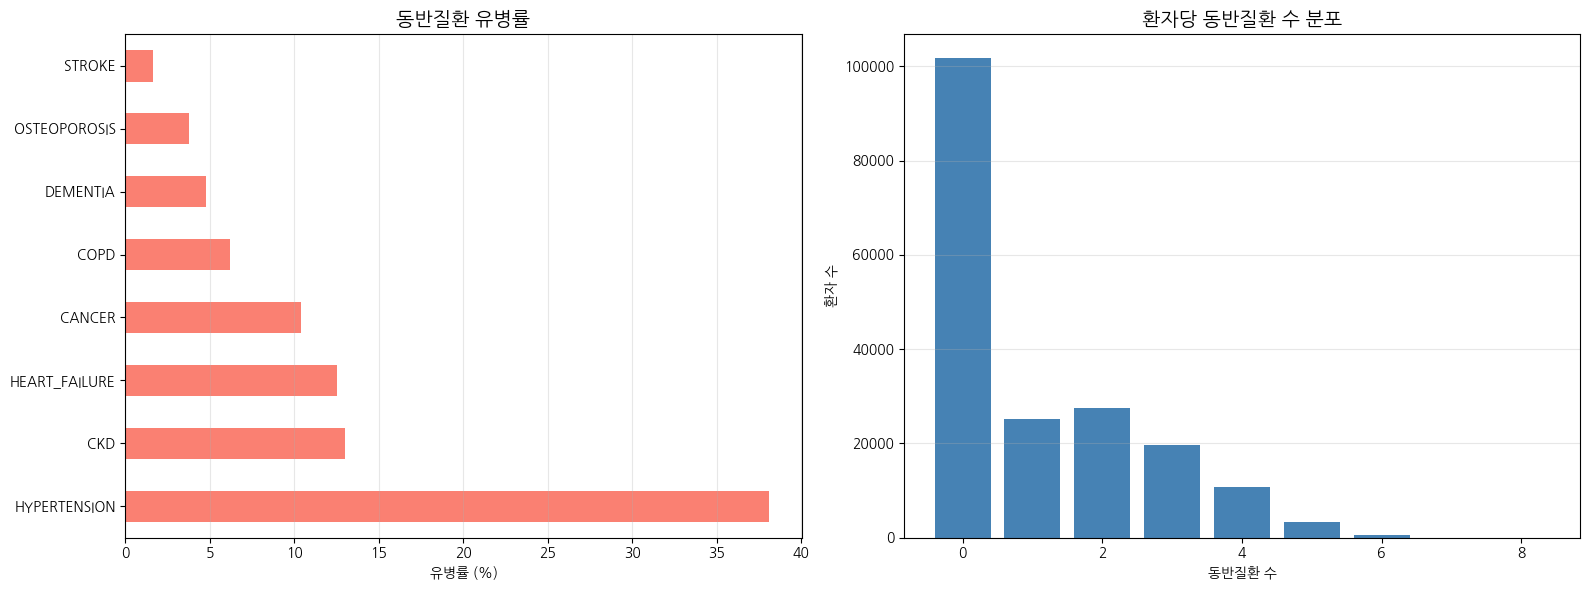

In [ ]:
# ============================================================================
# 5. 동반질환 (Comorbidities) 분석
# ============================================================================
print("\n📌 5. 동반질환 분석")
print("-"*80)

comorbidity_columns = ['CKD', 'OSTEOPOROSIS', 'HYPERTENSION',
                       'HEART_FAILURE', 'DEMENTIA', 'STROKE',
                       'COPD', 'CANCER']

# 가용한 comorbidity 컬럼만 선택
comorbidity_columns = [col for col in comorbidity_columns if col in nutrition_cohort.columns]

print("\n동반질환 유병률:")
comorbidity_counts = nutrition_cohort[comorbidity_columns].sum().sort_values(ascending=False)
comorbidity_pct = (comorbidity_counts / len(nutrition_cohort) * 100).round(2)

comorbidity_df = pd.DataFrame({
    '환자 수': comorbidity_counts,
    '유병률 (%)': comorbidity_pct
})
print(comorbidity_df)

# 동반질환 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 막대 그래프
comorbidity_pct.plot(kind='barh', ax=axes[0], color='salmon')
axes[0].set_xlabel('유병률 (%)')
axes[0].set_title('동반질환 유병률', fontweight='bold', fontsize=14)
axes[0].grid(alpha=0.3, axis='x')

# 동반질환 수 분포
if 'COMORBIDITY_COUNT' in nutrition_cohort.columns:
    comorbidity_count_dist = nutrition_cohort['COMORBIDITY_COUNT'].value_counts().sort_index()
    axes[1].bar(comorbidity_count_dist.index, comorbidity_count_dist.values, color='steelblue')
    axes[1].set_xlabel('동반질환 수')
    axes[1].set_ylabel('환자 수')
    axes[1].set_title('환자당 동반질환 수 분포', fontweight='bold', fontsize=14)
    axes[1].grid(alpha=0.3, axis='y')

    print(f"\n평균 동반질환 수: {nutrition_cohort['COMORBIDITY_COUNT'].mean():.2f}개")
    print(f"동반질환 없는 환자: {(nutrition_cohort['COMORBIDITY_COUNT'] == 0).sum()}명 ({(nutrition_cohort['COMORBIDITY_COUNT'] == 0).sum()/len(nutrition_cohort)*100:.1f}%)")

plt.tight_layout()
plt.show()



📌 7. 영양 지표와 동반질환 관계
--------------------------------------------------------------------------------


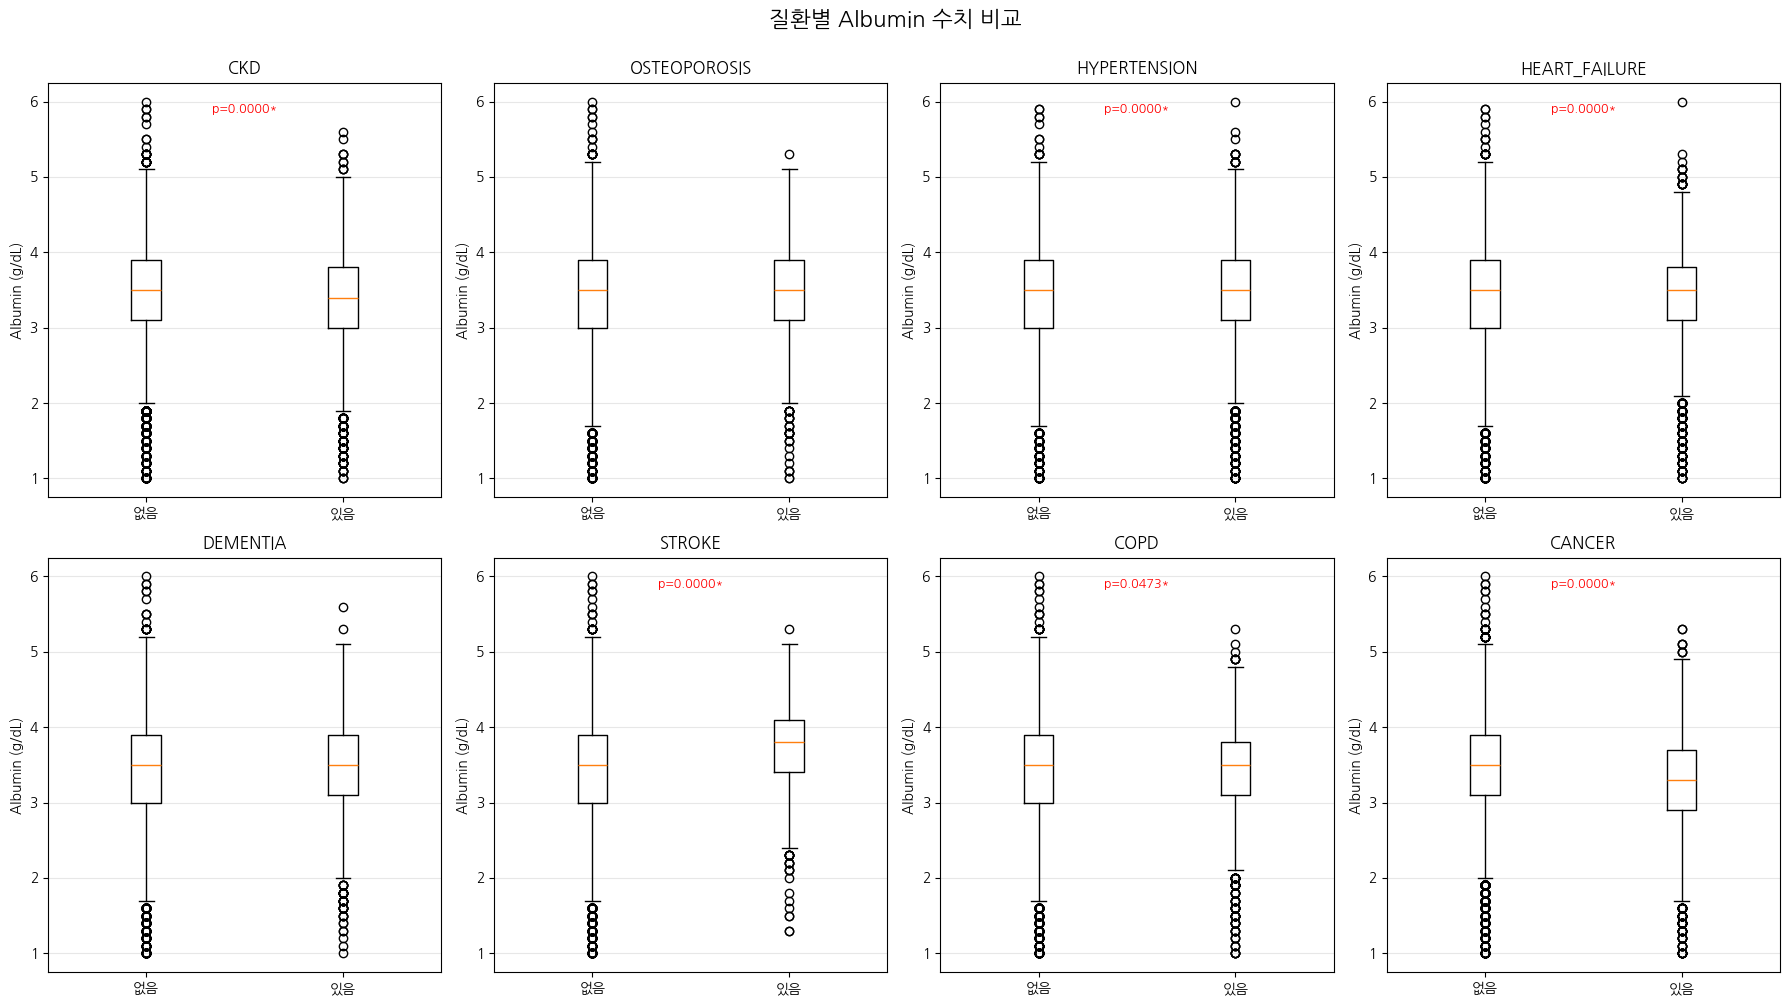

In [ ]:

# ============================================================================
# 7. 영양 지표와 동반질환 관계
# ============================================================================
print("\n📌 7. 영양 지표와 동반질환 관계")
print("-"*80)

# Albumin과 동반질환
if 'ALBUMIN' in nutrition_cohort.columns and len(comorbidity_columns) > 0:
    fig, axes = plt.subplots(2, 4, figsize=(18, 10))
    axes = axes.flatten()

    for idx, disease in enumerate(comorbidity_columns[:8]):
        if disease in nutrition_cohort.columns:
            data_yes = nutrition_cohort[nutrition_cohort[disease] == 1]['ALBUMIN'].dropna()
            data_no = nutrition_cohort[nutrition_cohort[disease] == 0]['ALBUMIN'].dropna()

            axes[idx].boxplot([data_no, data_yes], labels=['없음', '있음'])
            axes[idx].set_ylabel('Albumin (g/dL)')
            axes[idx].set_title(f'{disease}', fontweight='bold')
            axes[idx].grid(alpha=0.3, axis='y')

            # t-test
            if len(data_yes) > 0 and len(data_no) > 0:
                t_stat, p_value = stats.ttest_ind(data_no, data_yes, nan_policy='omit')
                if p_value < 0.05:
                    axes[idx].text(0.5, 0.95, f'p={p_value:.4f}*',
                                  transform=axes[idx].transAxes,
                                  ha='center', va='top', color='red', fontsize=9)

    plt.suptitle('질환별 Albumin 수치 비교', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()



📌 8. 영양 지표 간 상관관계
--------------------------------------------------------------------------------


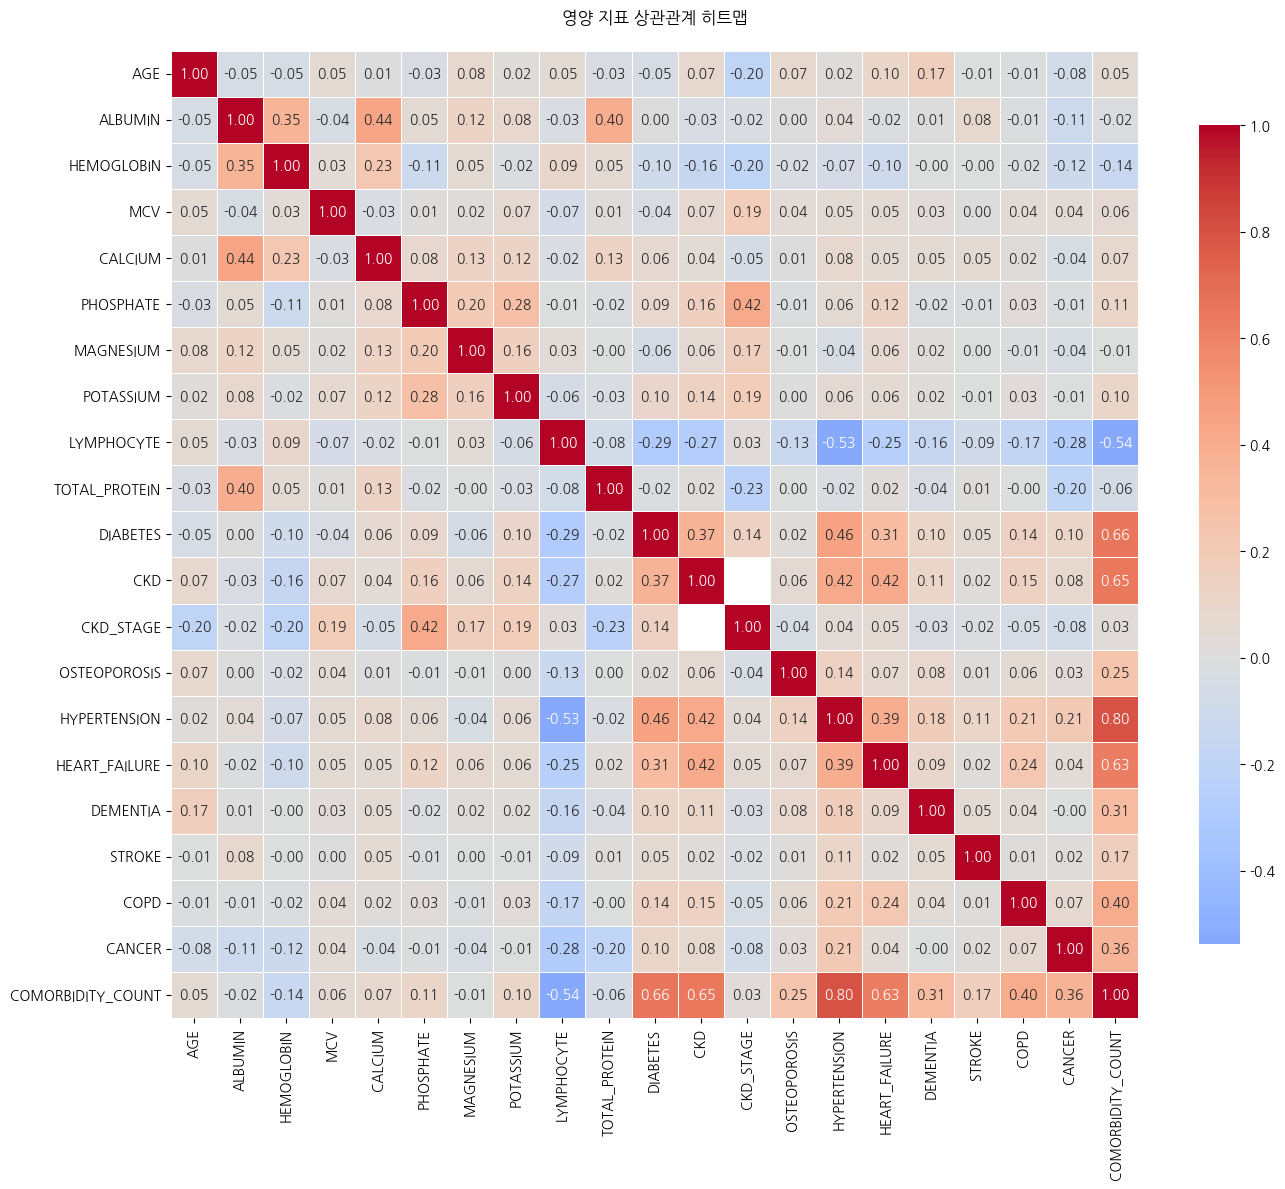


높은 상관관계 (|r| > 0.5):
          변수1               변수2      상관계수
 HYPERTENSION COMORBIDITY_COUNT  0.799256
     DIABETES COMORBIDITY_COUNT  0.655433
          CKD COMORBIDITY_COUNT  0.650045
HEART_FAILURE COMORBIDITY_COUNT  0.626723
   LYMPHOCYTE COMORBIDITY_COUNT -0.537388
   LYMPHOCYTE      HYPERTENSION -0.531742


In [ ]:
# ============================================================================
# 8. 상관관계 분석
# ============================================================================
print("\n📌 8. 영양 지표 간 상관관계")
print("-"*80)

# 연속형 변수만 선택
numeric_cols = nutrition_cohort.select_dtypes(include=[np.number]).columns
# ID 컬럼 제외
numeric_cols = [col for col in numeric_cols if col not in ['SUBJECT_ID', 'HADM_ID', 'ROW_ID']]

if len(numeric_cols) > 0:
    correlation_matrix = nutrition_cohort[numeric_cols].corr()

    plt.figure(figsize=(14, 12))
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('영양 지표 상관관계 히트맵', fontsize=12, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

    # 높은 상관관계 찾기
    print("\n높은 상관관계 (|r| > 0.5):")
    high_corr = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            if abs(correlation_matrix.iloc[i, j]) > 0.5:
                high_corr.append({
                    '변수1': correlation_matrix.columns[i],
                    '변수2': correlation_matrix.columns[j],
                    '상관계수': correlation_matrix.iloc[i, j]
                })

    if high_corr:
        high_corr_df = pd.DataFrame(high_corr).sort_values('상관계수', ascending=False, key=abs)
        print(high_corr_df.to_string(index=False))


📌 9. 영양 결핍 위험군 분석
--------------------------------------------------------------------------------

저알부민혈증 (Albumin < 3.5): 23313명 (12.3%)
빈혈 (Hemoglobin < 12): 104390명 (55.3%)

영양 결핍 위험 점수 분포:
NUTRITION_RISK_SCORE
0    37894
1    69913
2    57297
3    20482
4     3185
Name: count, dtype: int64


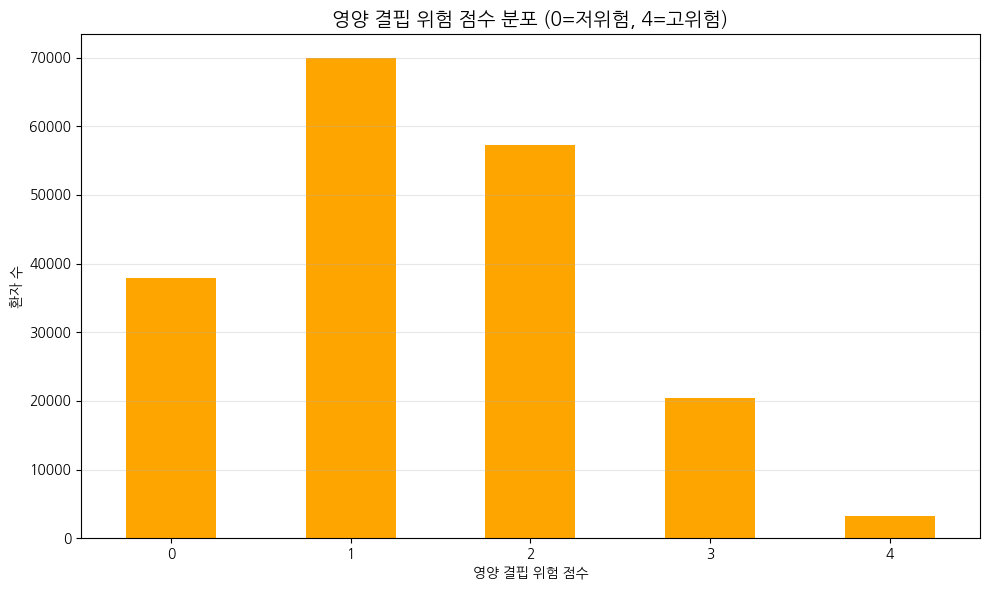

In [ ]:
# ============================================================================
# 9. 영양 결핍 위험군 식별
# ============================================================================
print("\n📌 9. 영양 결핍 위험군 분석")
print("-"*80)

# 영양 결핍 기준 (일반적인 임상 기준)
nutrition_cohort['LOW_ALBUMIN'] = (nutrition_cohort['ALBUMIN'] < 3.5).astype(int)
nutrition_cohort['LOW_HEMOGLOBIN'] = (nutrition_cohort['HEMOGLOBIN'] < 12).astype(int)

if 'LOW_ALBUMIN' in nutrition_cohort.columns:
    print(f"\n저알부민혈증 (Albumin < 3.5): {nutrition_cohort['LOW_ALBUMIN'].sum()}명 ({nutrition_cohort['LOW_ALBUMIN'].sum()/len(nutrition_cohort)*100:.1f}%)")

if 'LOW_HEMOGLOBIN' in nutrition_cohort.columns:
    print(f"빈혈 (Hemoglobin < 12): {nutrition_cohort['LOW_HEMOGLOBIN'].sum()}명 ({nutrition_cohort['LOW_HEMOGLOBIN'].sum()/len(nutrition_cohort)*100:.1f}%)")

# 영양 결핍 위험 점수 생성
nutrition_cohort['NUTRITION_RISK_SCORE'] = 0
if 'LOW_ALBUMIN' in nutrition_cohort.columns:
    nutrition_cohort['NUTRITION_RISK_SCORE'] += nutrition_cohort['LOW_ALBUMIN']
if 'LOW_HEMOGLOBIN' in nutrition_cohort.columns:
    nutrition_cohort['NUTRITION_RISK_SCORE'] += nutrition_cohort['LOW_HEMOGLOBIN']
if 'AGE' in nutrition_cohort.columns:
    nutrition_cohort['NUTRITION_RISK_SCORE'] += (nutrition_cohort['AGE'] > 75).astype(int)
if 'COMORBIDITY_COUNT' in nutrition_cohort.columns:
    nutrition_cohort['NUTRITION_RISK_SCORE'] += (nutrition_cohort['COMORBIDITY_COUNT'] >= 3).astype(int)

print(f"\n영양 결핍 위험 점수 분포:")
print(nutrition_cohort['NUTRITION_RISK_SCORE'].value_counts().sort_index())

plt.figure(figsize=(10, 6))
nutrition_cohort['NUTRITION_RISK_SCORE'].value_counts().sort_index().plot(kind='bar', color='orange')
plt.xlabel('영양 결핍 위험 점수')
plt.ylabel('환자 수')
plt.title('영양 결핍 위험 점수 분포 (0=저위험, 4=고위험)', fontweight='bold', fontsize=14)
plt.xticks(rotation=0)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# 10. 요약 통계
# ============================================================================
print("\n📌 10. 최종 요약")
print("="*80)
print(f"✅ 총 환자 수: {nutrition_cohort['SUBJECT_ID'].nunique():,}명")
print(f"✅ 평균 연령: {nutrition_cohort['AGE'].mean():.1f}세")
print(f"✅ 평균 동반질환 수: {nutrition_cohort['COMORBIDITY_COUNT'].mean():.1f}개")
if 'ALBUMIN' in nutrition_cohort.columns:
    print(f"✅ 평균 Albumin: {nutrition_cohort['ALBUMIN'].mean():.2f} g/dL")
if 'HEMOGLOBIN' in nutrition_cohort.columns:
    print(f"✅ 평균 Hemoglobin: {nutrition_cohort['HEMOGLOBIN'].mean():.2f} g/dL")
print(f"✅ 영양 결핍 고위험군 (점수 ≥3): {(nutrition_cohort['NUTRITION_RISK_SCORE'] >= 3).sum()}명")
print("="*80)


📌 10. 최종 요약
✅ 총 환자 수: 75,339명
✅ 평균 연령: 76.9세
✅ 평균 동반질환 수: 1.1개
✅ 평균 Albumin: 3.45 g/dL
✅ 평균 Hemoglobin: 10.97 g/dL
✅ 영양 결핍 고위험군 (점수 ≥3): 23667명


In [ ]:

print("\n📌 영양 추천 모델을 위한 특성 엔지니어링 제안")
print("="*80)

# 1. 영양소 결핍 프로파일링
nutrition_cohort['NEEDS_IRON'] = (nutrition_cohort['HEMOGLOBIN'] < 12).astype(int)
nutrition_cohort['NEEDS_PROTEIN'] = (nutrition_cohort['ALBUMIN'] < 3.5).astype(int)
nutrition_cohort['NEEDS_CALCIUM'] = (nutrition_cohort['CALCIUM'] < 8.5).astype(int)

# 2. 질환별 영양 니즈
nutrition_cohort['RENAL_DIET_NEEDED'] = nutrition_cohort['CKD'].astype(int)
nutrition_cohort['CARDIAC_DIET_NEEDED'] = nutrition_cohort['HEART_FAILURE'].astype(int)
nutrition_cohort['DIABETIC_DIET_NEEDED'] = 0  # 당뇨 컬럼 있으면 추가

# 3. 종합 영양 프로파일
print("\n추천 우선순위가 높은 환자군:")
high_priority = nutrition_cohort[
    (nutrition_cohort['NUTRITION_RISK_SCORE'] >= 3) |
    (nutrition_cohort['COMORBIDITY_COUNT'] >= 3)
]
print(f"고위험 환자: {len(high_priority)}명 ({len(high_priority)/len(nutrition_cohort)*100:.1f}%)")



📌 영양 추천 모델을 위한 특성 엔지니어링 제안

추천 우선순위가 높은 환자군:
고위험 환자: 40876명 (21.7%)


# 결측치 및 이상치 상세 분석
- 이상치 분석 결과 제거 대상 0건



In [ ]:
# 1-1. 결측치 현황 상세 분석
missing_analysis = pd.DataFrame({
    'Missing_Count': nutrition_cohort.isnull().sum(),
    'Missing_Percent': (nutrition_cohort.isnull().sum() / len(nutrition_cohort) * 100).round(2),
    'Data_Type': nutrition_cohort.dtypes,
    'Unique_Values': nutrition_cohort.nunique(),
    'Non_Null_Count': nutrition_cohort.count()
})
missing_analysis = missing_analysis[missing_analysis['Missing_Count'] > 0].sort_values('Missing_Percent', ascending=False)

print("\n📊 결측치가 있는 변수:")
print(missing_analysis)


📊 결측치가 있는 변수:
               Missing_Count  Missing_Percent Data_Type  Unique_Values  \
TOTAL_PROTEIN         186430            98.76   float64             42   
CKD_STAGE             173130            91.71   float64              6   
ALBUMIN               139611            73.96   float64             51   
LYMPHOCYTE            131197            69.50   float64            996   
PHOSPHATE              46075            24.41   float64             71   
CALCIUM                44978            23.83   float64            100   
MAGNESIUM              41541            22.01   float64             44   
MCV                    32197            17.06   float64             79   
HEMOGLOBIN             31194            16.52   float64            165   
POTASSIUM              28560            15.13   float64             53   

               Non_Null_Count  
TOTAL_PROTEIN            2341  
CKD_STAGE               15641  
ALBUMIN                 49160  
LYMPHOCYTE              57574  
PHOSPHATE 

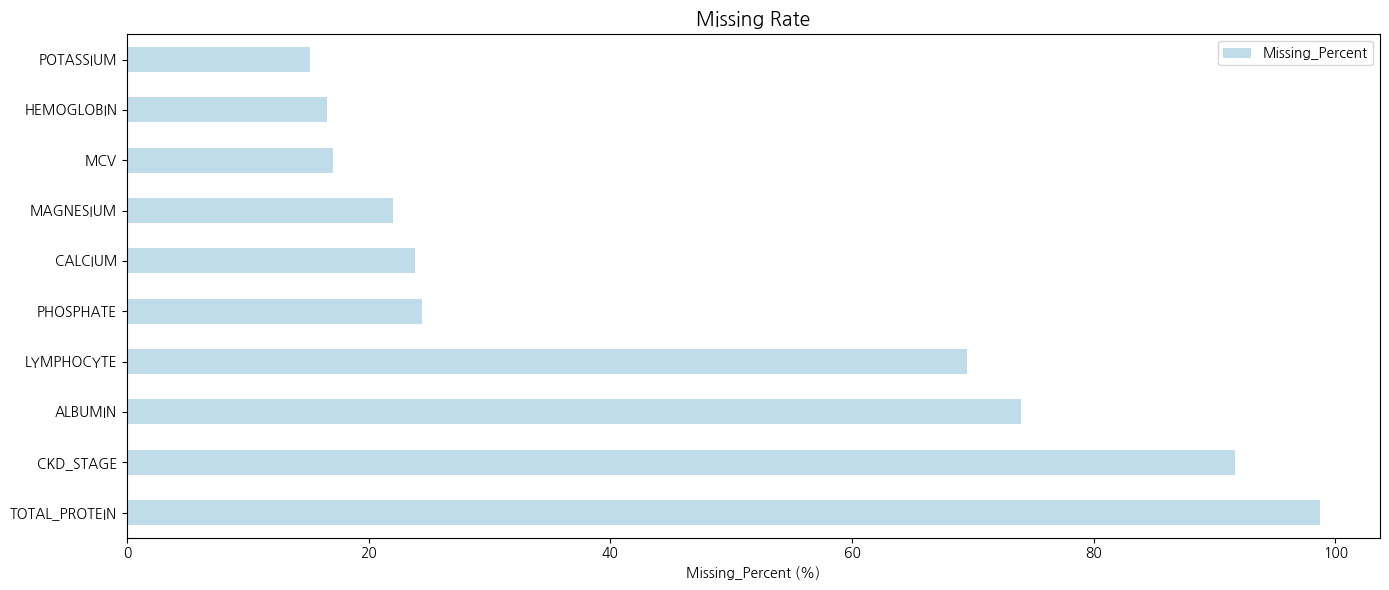

In [ ]:
# 1-2. 결측치 패턴 시각화
# 🌸 Pastel color palette (Healthcare / Dashboard friendly)
COLORS = {
    'primary':   '#A6CEE3',  # 파스텔 블루 (기본 지표)
    'secondary': '#B5EAD7',  # 파스텔 민트 (개선/긍정)
    'success':   '#C7E9C0',  # 파스텔 그린 (정상/안정)
    'warning':   '#FFE5B4',  # 파스텔 옐로우 (주의)
    'danger':    '#FB9A99',  # 파스텔 핑크레드 (위험)
    'info':      '#D7C2F0',  # 파스텔 퍼플 (보조정보)
    'neutral':   '#E0E0E0',  # 연한 그레이
    'dark':      '#6E6E6E'   # 텍스트용 다크 그레이
}

if len(missing_analysis) > 0:
    plt.figure(figsize=(14, 6))
    missing_analysis['Missing_Percent'].plot(kind='barh', color=COLORS['primary'], alpha=0.7)
    plt.xlabel('Missing_Percent (%)')
    plt.title('Missing Rate', fontweight='bold', fontsize=14)
    plt.legend()
    plt.tight_layout()
    plt.show()


🏥 Lab 수치: 임상 기준 기반 이상치 처리

📊 각 Lab 수치의 분포 분석 (임상 기준 대비)

📌 ALBUMIN (g/dL)
   전체: 49,160개
   범위: [1.00, 6.00]
   평균: 3.45 ± 0.62
   중앙값: 3.50

   🏥 임상 분류:
      🔴 생존 범위 미만 (<1.0): 0개 (0.00%)
      🟡 낮음 (1.0-3.5): 23,313개 (47.42%)
      🟢 정상 (3.5-5.5): 25,840개 (52.56%)
      🟡 높음 (5.5-6.5): 7개 (0.01%)
      🔴 생존 범위 초과 (>6.5): 0개 (0.00%)

   ✂️  제거 대상 (<0.5 또는 >7.0): 0개 (0.00%)

📌 HEMOGLOBIN (g/dL)
   전체: 157,577개
   범위: [3.00, 20.00]
   평균: 10.97 ± 2.16
   중앙값: 11.10

   🏥 임상 분류:
      🔴 생존 범위 미만 (<3.0): 0개 (0.00%)
      🟡 낮음 (3.0-12.0): 104,390개 (66.25%)
      🟢 정상 (12.0-17.5): 53,109개 (33.70%)
      🟡 높음 (17.5-22.0): 78개 (0.05%)
      🔴 생존 범위 초과 (>22.0): 0개 (0.00%)

   ✂️  제거 대상 (<2.0 또는 >25.0): 0개 (0.00%)

📌 MCV (fL)
   전체: 156,574개
   범위: [52.00, 120.00]
   평균: 91.36 ± 7.00
   중앙값: 91.00

   🏥 임상 분류:
      🔴 생존 범위 미만 (<50): 0개 (0.00%)
      🟡 낮음 (50-80): 6,983개 (4.46%)
      🟢 정상 (80-100): 136,967개 (87.48%)
      🟡 높음 (100-125): 12,624개 (8.06%)
      🔴 생존 범위 초과 (>125): 0개 (0.00%)

  

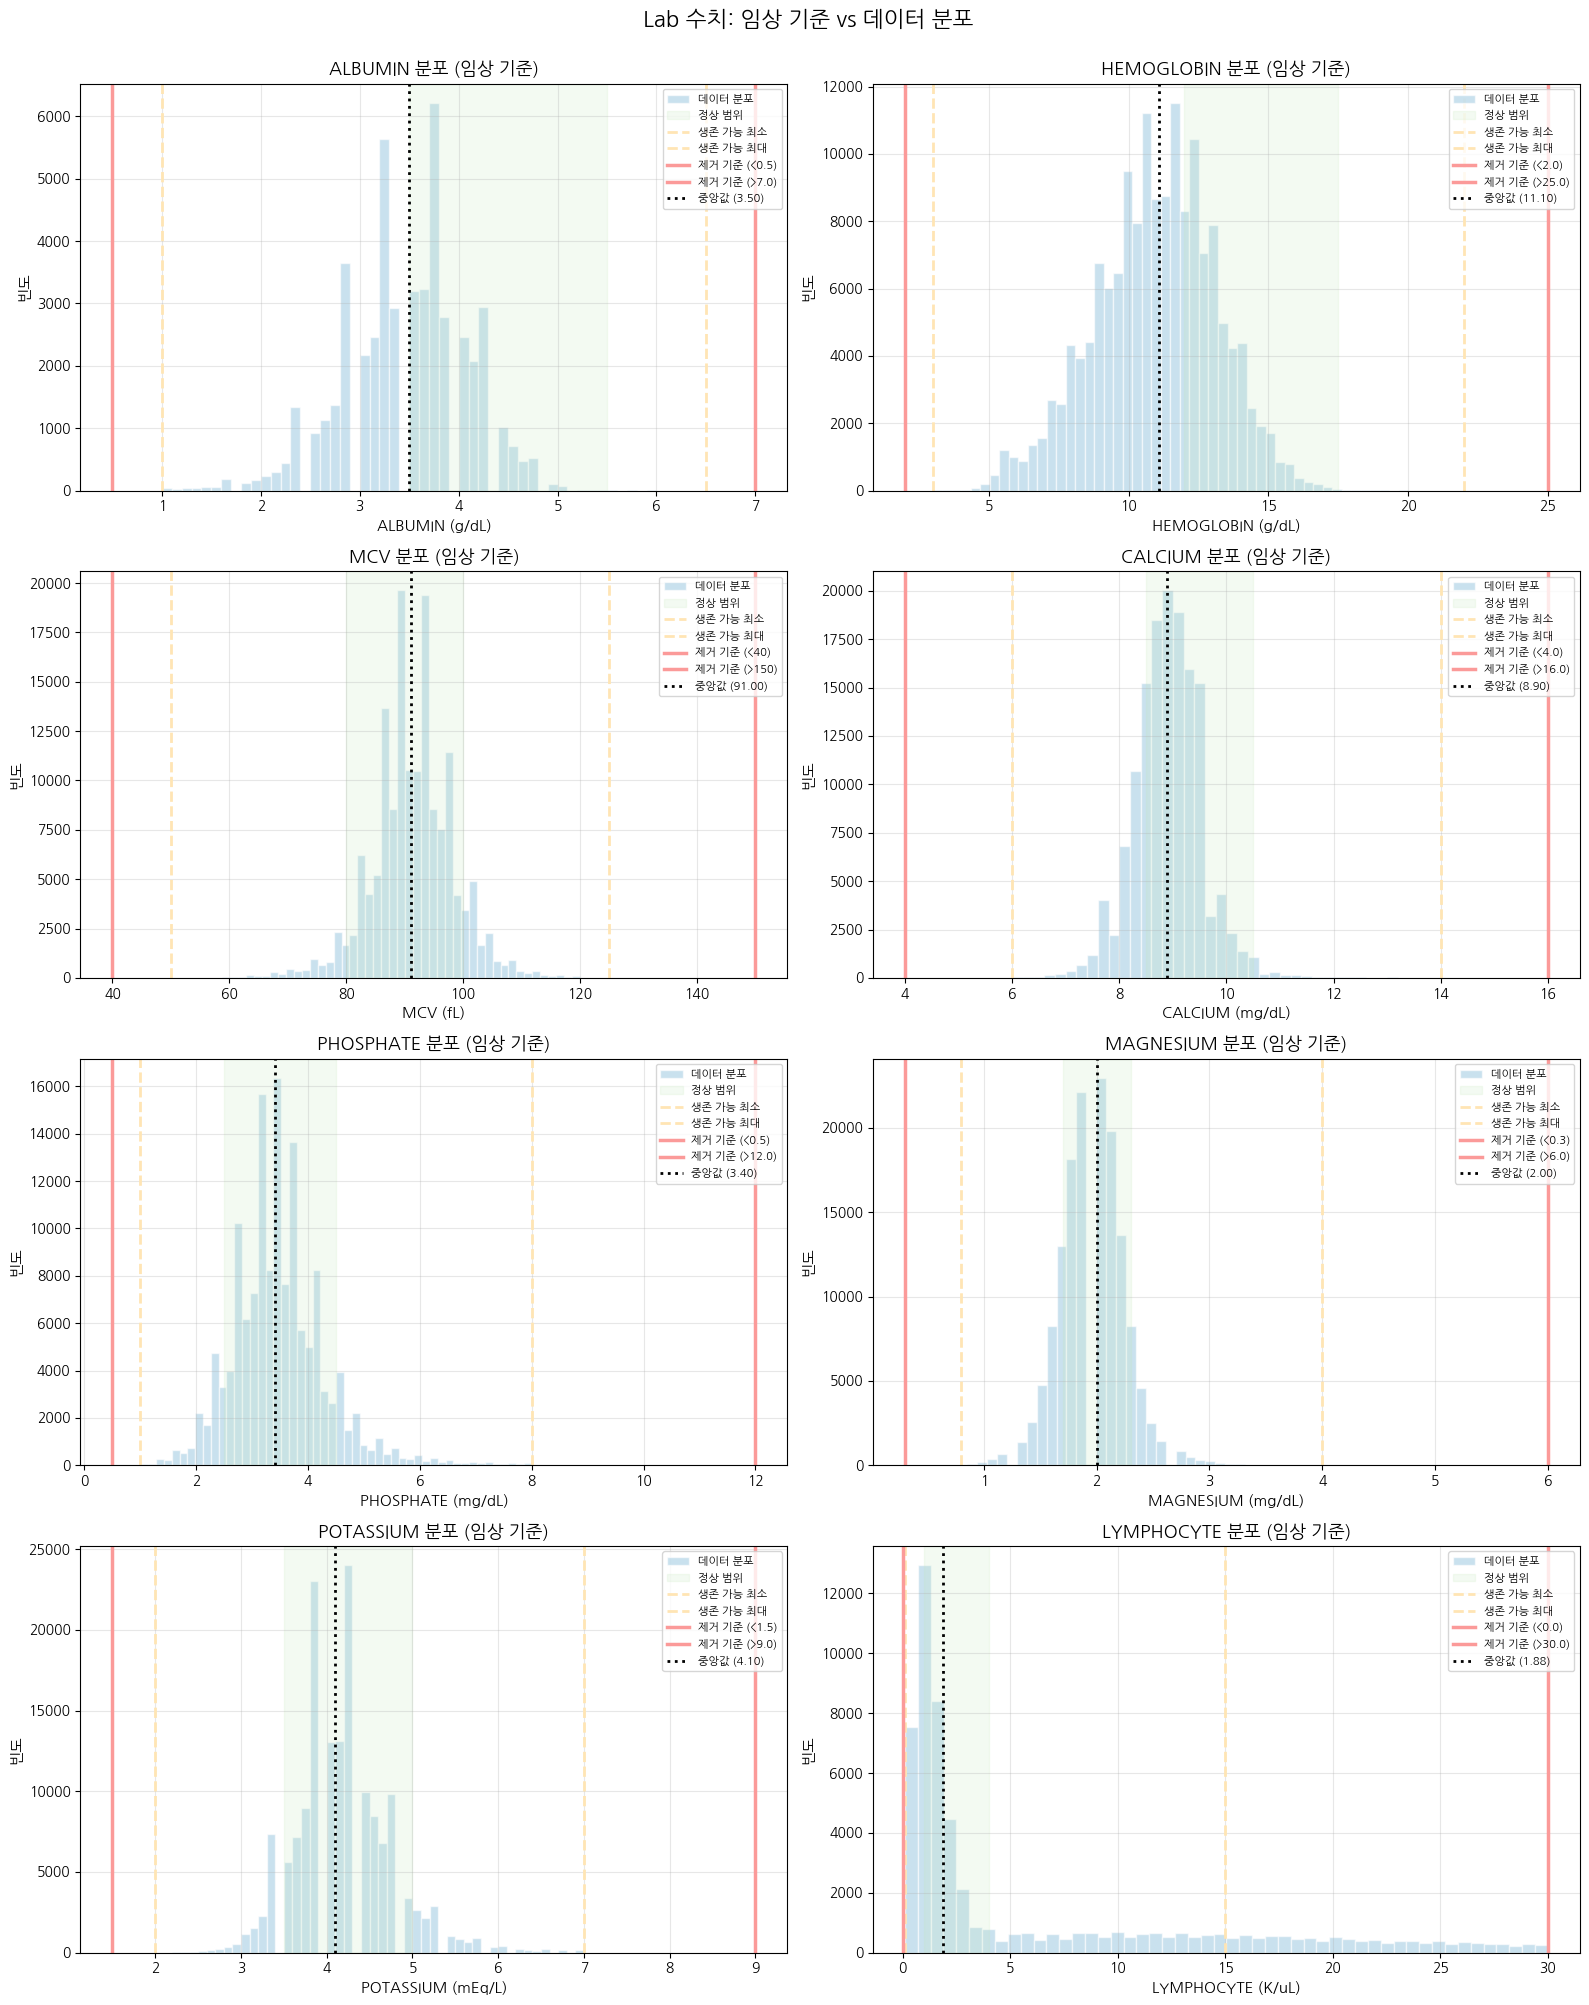

In [ ]:
# ============================================================================
# 🏥 Lab 수치 임상 기준 (의학적으로 정확한 범위)
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("="*80)
print("🏥 Lab 수치: 임상 기준 기반 이상치 처리")
print("="*80)

# ──────────────────────────────────────────────────────────────────────────
# 📋 임상 정상 범위 및 생리학적 가능 범위
# ──────────────────────────────────────────────────────────────────────────

LAB_CLINICAL_RANGES = {
    'ALBUMIN': {
        'normal_range': (3.5, 5.5),      # 정상 범위 (g/dL)
        'viable_range': (1.0, 6.5),      # 생존 가능 범위
        'unit': 'g/dL',
        'interpretation': {
            'low': '< 3.5 (저알부민혈증: 영양실조, 간질환, 신증후군)',
            'normal': '3.5-5.5 (정상)',
            'high': '> 5.5 (탈수)'
        },
        'remove_below': 0.5,  # 측정 오류 가능성
        'remove_above': 7.0   # 생리학적 불가능
    },

    'HEMOGLOBIN': {
        'normal_range': (12.0, 17.5),    # 정상 범위 (g/dL) - 성별 통합
        'normal_male': (13.5, 17.5),     # 남성
        'normal_female': (12.0, 15.5),   # 여성
        'viable_range': (3.0, 22.0),
        'unit': 'g/dL',
        'interpretation': {
            'low': '< 12 (빈혈: 철분/비타민 B12/엽산 결핍)',
            'normal': '12-17.5 (정상)',
            'high': '> 17.5 (다혈구증, 탈수)'
        },
        'remove_below': 2.0,   # 생명 유지 어려움
        'remove_above': 25.0   # 측정 오류
    },

    'MCV': {
        'normal_range': (80, 100),       # 정상 범위 (fL)
        'viable_range': (50, 125),
        'unit': 'fL',
        'interpretation': {
            'low': '< 80 (소구성 빈혈: 철분 결핍)',
            'normal': '80-100 (정상)',
            'high': '> 100 (대구성 빈혈: B12/엽산 결핍)'
        },
        'remove_below': 40,
        'remove_above': 150
    },

    'CALCIUM': {
        'normal_range': (8.5, 10.5),     # 정상 범위 (mg/dL)
        'viable_range': (6.0, 14.0),
        'unit': 'mg/dL',
        'interpretation': {
            'low': '< 8.5 (저칼슘혈증: 비타민D 결핍, 부갑상선 기능저하)',
            'normal': '8.5-10.5 (정상)',
            'high': '> 10.5 (고칼슘혈증: 부갑상선 기능항진, 암)'
        },
        'remove_below': 4.0,
        'remove_above': 16.0
    },

    'PHOSPHATE': {
        'normal_range': (2.5, 4.5),      # 정상 범위 (mg/dL)
        'viable_range': (1.0, 8.0),
        'unit': 'mg/dL',
        'interpretation': {
            'low': '< 2.5 (저인산혈증)',
            'normal': '2.5-4.5 (정상)',
            'high': '> 4.5 (고인산혈증: CKD)'
        },
        'remove_below': 0.5,
        'remove_above': 12.0
    },

    'MAGNESIUM': {
        'normal_range': (1.7, 2.3),      # 정상 범위 (mg/dL)
        'viable_range': (0.8, 4.0),
        'unit': 'mg/dL',
        'interpretation': {
            'low': '< 1.7 (저마그네슘혈증: 흡수 장애, 이뇨제)',
            'normal': '1.7-2.3 (정상)',
            'high': '> 2.3 (고마그네슘혈증: 신부전)'
        },
        'remove_below': 0.3,
        'remove_above': 6.0
    },

    'POTASSIUM': {
        'normal_range': (3.5, 5.0),      # 정상 범위 (mEq/L)
        'viable_range': (2.0, 7.0),      # 생명 유지 가능
        'unit': 'mEq/L',
        'interpretation': {
            'low': '< 3.5 (저칼륨혈증: 부정맥 위험)',
            'normal': '3.5-5.0 (정상)',
            'high': '> 5.0 (고칼륨혈증: CKD, 심장 정지 위험)'
        },
        'remove_below': 1.5,   # 심각한 부정맥
        'remove_above': 9.0    # 측정 오류 또는 용혈
    },

    'LYMPHOCYTE': {
        'normal_range': (1.0, 4.0),      # 정상 범위 (K/uL or 10^3/uL)
        'viable_range': (0.1, 15.0),
        'unit': 'K/uL',
        'interpretation': {
            'low': '< 1.0 (림프구감소증: 면역저하, HIV, 화학요법)',
            'normal': '1.0-4.0 (정상)',
            'high': '> 4.0 (림프구증가증: 감염, 백혈병)'
        },
        'remove_below': 0.0,   # 음수 불가
        'remove_above': 30.0   # 급성 백혈병도 보통 < 30
    }
}


# ──────────────────────────────────────────────────────────────────────────
# 📊 현재 데이터의 분포 vs 임상 기준
# ──────────────────────────────────────────────────────────────────────────

print("\n📊 각 Lab 수치의 분포 분석 (임상 기준 대비)")
print("="*80)

for var, ranges in LAB_CLINICAL_RANGES.items():
    if var not in nutrition_cohort.columns:
        print(f"\n⚠️  {var}: 데이터에 없음")
        continue

    data = nutrition_cohort[var].dropna()

    if len(data) == 0:
        continue

    # 통계
    normal_low, normal_high = ranges['normal_range']
    viable_low, viable_high = ranges['viable_range']
    remove_low = ranges['remove_below']
    remove_high = ranges['remove_above']

    # 분류
    below_viable = (data < viable_low).sum()
    in_low = ((data >= viable_low) & (data < normal_low)).sum()
    in_normal = ((data >= normal_low) & (data <= normal_high)).sum()
    in_high = ((data > normal_high) & (data <= viable_high)).sum()
    above_viable = (data > viable_high).sum()

    # 제거 대상
    to_remove = ((data < remove_low) | (data > remove_high)).sum()

    print(f"\n📌 {var} ({ranges['unit']})")
    print(f"   전체: {len(data):,}개")
    print(f"   범위: [{data.min():.2f}, {data.max():.2f}]")
    print(f"   평균: {data.mean():.2f} ± {data.std():.2f}")
    print(f"   중앙값: {data.median():.2f}")
    print(f"\n   🏥 임상 분류:")
    print(f"      🔴 생존 범위 미만 (<{viable_low}): {below_viable:,}개 ({below_viable/len(data)*100:.2f}%)")
    print(f"      🟡 낮음 ({viable_low}-{normal_low}): {in_low:,}개 ({in_low/len(data)*100:.2f}%)")
    print(f"      🟢 정상 ({normal_low}-{normal_high}): {in_normal:,}개 ({in_normal/len(data)*100:.2f}%)")
    print(f"      🟡 높음 ({normal_high}-{viable_high}): {in_high:,}개 ({in_high/len(data)*100:.2f}%)")
    print(f"      🔴 생존 범위 초과 (>{viable_high}): {above_viable:,}개 ({above_viable/len(data)*100:.2f}%)")
    print(f"\n   ✂️  제거 대상 (<{remove_low} 또는 >{remove_high}): {to_remove:,}개 ({to_remove/len(data)*100:.2f}%)")


# ──────────────────────────────────────────────────────────────────────────
# 📊 시각화: 임상 기준 vs 데이터 분포
# ──────────────────────────────────────────────────────────────────────────

lab_vars_available = [var for var in LAB_CLINICAL_RANGES.keys()
                      if var in nutrition_cohort.columns]

n_vars = len(lab_vars_available)
n_cols = 2
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*5))
axes = axes.flatten() if n_vars > 1 else [axes]

for idx, var in enumerate(lab_vars_available):
    if idx >= len(axes):
        break

    data = nutrition_cohort[var].dropna()
    ranges = LAB_CLINICAL_RANGES[var]

    # 히스토그램
    axes[idx].hist(data, bins=50, color=COLORS['primary'],
                   edgecolor='white', alpha=0.6, label='데이터 분포')

    # 정상 범위 (녹색 영역)
    normal_low, normal_high = ranges['normal_range']
    axes[idx].axvspan(normal_low, normal_high, alpha=0.2,
                     color=COLORS['success'], label='정상 범위')

    # 생존 가능 범위 (노란색 선)
    viable_low, viable_high = ranges['viable_range']
    axes[idx].axvline(viable_low, color=COLORS['warning'],
                     linestyle='--', linewidth=2, label='생존 가능 최소')
    axes[idx].axvline(viable_high, color=COLORS['warning'],
                     linestyle='--', linewidth=2, label='생존 가능 최대')

    # 제거 기준 (빨간색 선)
    remove_low = ranges['remove_below']
    remove_high = ranges['remove_above']
    axes[idx].axvline(remove_low, color=COLORS['danger'],
                     linestyle='-', linewidth=2.5, label=f'제거 기준 (<{remove_low})')
    axes[idx].axvline(remove_high, color=COLORS['danger'],
                     linestyle='-', linewidth=2.5, label=f'제거 기준 (>{remove_high})')

    # 중앙값
    axes[idx].axvline(data.median(), color='black',
                     linestyle=':', linewidth=2, label=f'중앙값 ({data.median():.2f})')

    axes[idx].set_xlabel(f'{var} ({ranges["unit"]})', fontweight='bold', fontsize=11)
    axes[idx].set_ylabel('빈도', fontweight='bold', fontsize=11)
    axes[idx].set_title(f'{var} 분포 (임상 기준)', fontsize=13, fontweight='bold')
    axes[idx].legend(fontsize=8, loc='upper right')
    axes[idx].grid(alpha=0.3)

for idx in range(n_vars, len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('🏥 Lab 수치: 임상 기준 vs 데이터 분포',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# 행별 30% 미만 제거


🗑️ STEP 2: 정보가 부족한 행 제거
📌 주요 Lab 변수 (8개):
   ['ALBUMIN', 'HEMOGLOBIN', 'MCV', 'CALCIUM', 'PHOSPHATE', 'MAGNESIUM', 'POTASSIUM', 'LYMPHOCYTE']

📊 행별 채워진 비율 분포:
count    188771.000000
mean         67.198815
std          32.008725
min           0.000000
25%          62.500000
50%          75.000000
75%          87.500000
max         100.000000
Name: ROW_FILLED_PCT, dtype: float64


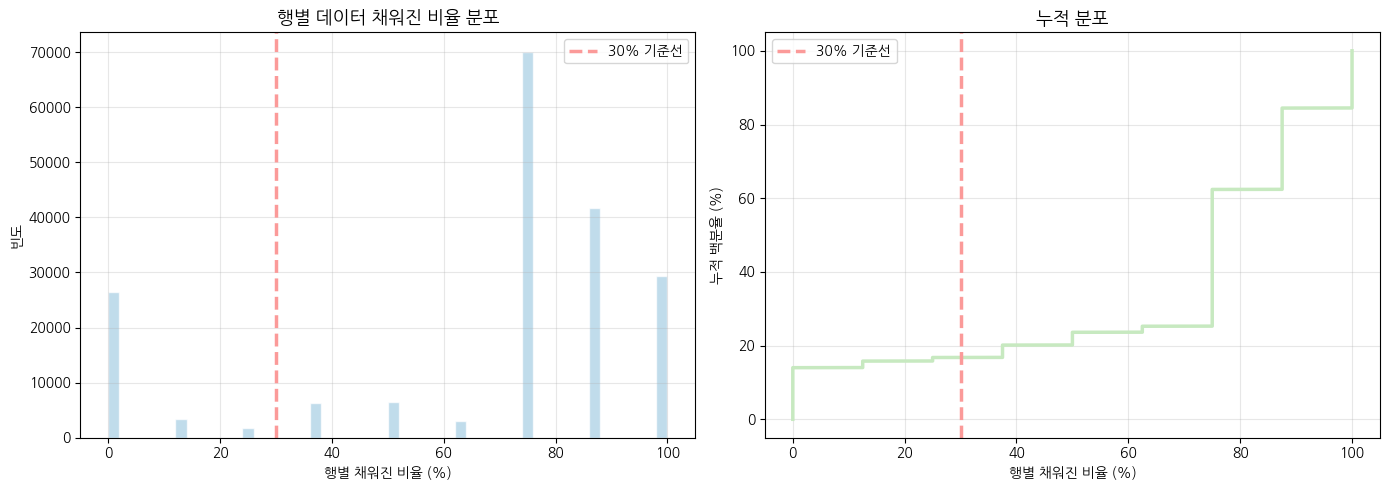


🗑️ 제거 대상:
   - 기준: 주요 Lab 변수 중 30% 미만 채워진 행
   - 제거할 행: 31,655개 (16.77%)

✅ 제거 완료:
   - 이전: 188,771행
   - 이후: 157,116행
   - 제거: 31,655행 (16.77%)


In [ ]:

# ============================================================================
# STEP 2: 행별 결측 비율 높은 샘플 제거 ⭐ 가장 중요!
# ============================================================================
print("\n" + "="*80)
print("🗑️ STEP 2: 정보가 부족한 행 제거")
print("="*80)

# 주요 Lab 변수들만 선택 (결측 판단 기준)
key_lab_vars = ['ALBUMIN', 'HEMOGLOBIN', 'MCV', 'CALCIUM', 'PHOSPHATE',
                'MAGNESIUM', 'POTASSIUM', 'LYMPHOCYTE']
key_lab_vars = [var for var in key_lab_vars if var in nutrition_cohort.columns]

print(f"📌 주요 Lab 변수 ({len(key_lab_vars)}개):")
print(f"   {key_lab_vars}")

# 행별 결측 비율 계산
nutrition_cohort['ROW_MISSING_PCT'] = (
    nutrition_cohort[key_lab_vars].isnull().sum(axis=1) / len(key_lab_vars) * 100
)

# 행별 채워진 비율 계산
nutrition_cohort['ROW_FILLED_PCT'] = 100 - nutrition_cohort['ROW_MISSING_PCT']

print(f"\n📊 행별 채워진 비율 분포:")
print(nutrition_cohort['ROW_FILLED_PCT'].describe())

# 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(nutrition_cohort['ROW_FILLED_PCT'], bins=50,
             color=COLORS['primary'], edgecolor='white', alpha=0.7)
axes[0].axvline(30, color=COLORS['danger'], linestyle='--', linewidth=2.5,
               label='30% 기준선')
axes[0].set_xlabel('행별 채워진 비율 (%)', fontweight='bold')
axes[0].set_ylabel('빈도', fontweight='bold')
axes[0].set_title('행별 데이터 채워진 비율 분포', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 누적 분포
sorted_pct = np.sort(nutrition_cohort['ROW_FILLED_PCT'])
cumulative = np.arange(1, len(sorted_pct) + 1) / len(sorted_pct) * 100
axes[1].plot(sorted_pct, cumulative, color=COLORS['success'], linewidth=2.5)
axes[1].axvline(30, color=COLORS['danger'], linestyle='--', linewidth=2.5,
               label='30% 기준선')
axes[1].set_xlabel('행별 채워진 비율 (%)', fontweight='bold')
axes[1].set_ylabel('누적 백분율 (%)', fontweight='bold')
axes[1].set_title('누적 분포', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 30% 미만 채워진 행 제거
threshold = 30
before_rows = len(nutrition_cohort)
low_quality_rows = nutrition_cohort['ROW_FILLED_PCT'] < threshold

print(f"\n🗑️ 제거 대상:")
print(f"   - 기준: 주요 Lab 변수 중 {threshold}% 미만 채워진 행")
print(f"   - 제거할 행: {low_quality_rows.sum():,}개 ({low_quality_rows.sum()/before_rows*100:.2f}%)")

nutrition_cohort = nutrition_cohort[~low_quality_rows].copy()
after_rows = len(nutrition_cohort)

print(f"\n✅ 제거 완료:")
print(f"   - 이전: {before_rows:,}행")
print(f"   - 이후: {after_rows:,}행")
print(f"   - 제거: {before_rows - after_rows:,}행 ({(before_rows - after_rows)/before_rows*100:.2f}%)")

# 임시 컬럼 제거
nutrition_cohort = nutrition_cohort.drop(columns=['ROW_MISSING_PCT', 'ROW_FILLED_PCT'])



# 변수별 결측치 처리

In [ ]:
# ============================================================================
# STEP 3: 변수별 결측치 처리
# ============================================================================
print("\n" + "="*80)
print("🛠️ STEP 3: 변수별 결측치 처리")
print("="*80)

# 3-1. 변수 DROP
drop_vars = ['CKD_STAGE', 'TOTAL_PROTEIN']

print(f"\n📌 3-1. 변수 제거")
for var in drop_vars:
    if var in nutrition_cohort.columns:
        nutrition_cohort = nutrition_cohort.drop(columns=[var])
        print(f"   ❌ {var} 제거")

# 3-2. MEDIAN + INDICATOR
median_indicator_vars = ['ALBUMIN', 'LYMPHOCYTE']

print(f"\n📌 3-2. MEDIAN + INDICATOR 처리")
for var in median_indicator_vars:
    if var in nutrition_cohort.columns:
        missing_count = nutrition_cohort[var].isnull().sum()
        missing_pct = (missing_count / len(nutrition_cohort)) * 100

        # Indicator 생성
        nutrition_cohort[f'{var}_MISSING'] = nutrition_cohort[var].isnull().astype(int)

        # Median 대체 (이제 더 정확한 median!)
        median_val = nutrition_cohort[var].median()
        nutrition_cohort[var].fillna(median_val, inplace=True)

        print(f"   ✅ {var}:")
        print(f"      - 결측: {missing_count:,}개 ({missing_pct:.2f}%)")
        print(f"      - 중앙값: {median_val:.2f}로 대체")
        print(f"      - Indicator: {var}_MISSING 생성")

# 3-3. MEDIAN 처리
median_vars = ['PHOSPHATE', 'CALCIUM', 'MAGNESIUM', 'MCV', 'HEMOGLOBIN', 'POTASSIUM']

print(f"\n📌 3-3. MEDIAN 처리")
for var in median_vars:
    if var in nutrition_cohort.columns:
        missing_count = nutrition_cohort[var].isnull().sum()

        if missing_count > 0:
            missing_pct = (missing_count / len(nutrition_cohort)) * 100
            median_val = nutrition_cohort[var].median()
            nutrition_cohort[var].fillna(median_val, inplace=True)

            print(f"   ✅ {var}: {missing_count:,}개 ({missing_pct:.2f}%) → {median_val:.2f}")
        else:
            print(f"   ✅ {var}: 결측 없음")

# 3-4. 기타 변수 처리
print(f"\n📌 3-4. 기타 변수 처리")

# ID
for col in ['SUBJECT_ID', 'HADM_ID']:
    if col in nutrition_cohort.columns:
        before = len(nutrition_cohort)
        nutrition_cohort = nutrition_cohort.dropna(subset=[col])
        after = len(nutrition_cohort)
        if before != after:
            print(f"   ⚠️ {col} 결측 제거: {before - after}행")

# AGE
if 'AGE' in nutrition_cohort.columns:
    age_missing = nutrition_cohort['AGE'].isnull().sum()
    if age_missing > 0:
        nutrition_cohort['AGE'].fillna(nutrition_cohort['AGE'].median(), inplace=True)
        print(f"   ✅ AGE: {age_missing}개 → 중앙값 대체")

# 질환
disease_vars = ['CKD', 'DIABETES', 'HYPERTENSION', 'HEART_FAILURE',
                'COPD', 'CANCER', 'STROKE', 'DEMENTIA', 'OSTEOPOROSIS']
for var in disease_vars:
    if var in nutrition_cohort.columns:
        missing = nutrition_cohort[var].isnull().sum()
        if missing > 0:
            nutrition_cohort[var].fillna(0, inplace=True)
            print(f"   ✅ {var}: {missing}개 → 0 (없음)")

# COMORBIDITY_COUNT 재계산
if 'COMORBIDITY_COUNT' in nutrition_cohort.columns:
    available = [d for d in disease_vars if d in nutrition_cohort.columns]
    nutrition_cohort['COMORBIDITY_COUNT'] = nutrition_cohort[available].sum(axis=1)
    print(f"   ✅ COMORBIDITY_COUNT 재계산")

# 남은 결측치 자동 처리
remaining = nutrition_cohort.isnull().sum()
remaining = remaining[remaining > 0]

if len(remaining) > 0:
    print(f"\n📌 3-5. 남은 결측치 자동 처리")
    for col in remaining.index:
        if nutrition_cohort[col].dtype in ['float64', 'int64']:
            med = nutrition_cohort[col].median()
            nutrition_cohort[col].fillna(med, inplace=True)
            print(f"   ✅ {col}: 중앙값 {med:.2f}")
        else:
            nutrition_cohort[col].fillna('Unknown', inplace=True)
            print(f"   ✅ {col}: Unknown")


🛠️ STEP 3: 변수별 결측치 처리

📌 3-1. 변수 제거
   ❌ CKD_STAGE 제거
   ❌ TOTAL_PROTEIN 제거

📌 3-2. MEDIAN + INDICATOR 처리
   ✅ ALBUMIN:
      - 결측: 108,018개 (68.75%)
      - 중앙값: 3.50로 대체
      - Indicator: ALBUMIN_MISSING 생성
   ✅ LYMPHOCYTE:
      - 결측: 99,558개 (63.37%)
      - 중앙값: 1.88로 대체
      - Indicator: LYMPHOCYTE_MISSING 생성

📌 3-3. MEDIAN 처리
   ✅ PHOSPHATE: 14,424개 (9.18%) → 3.40
   ✅ CALCIUM: 13,545개 (8.62%) → 8.90
   ✅ MAGNESIUM: 10,445개 (6.65%) → 2.00
   ✅ MCV: 1,632개 (1.04%) → 91.00
   ✅ HEMOGLOBIN: 1,263개 (0.80%) → 11.10
   ✅ POTASSIUM: 276개 (0.18%) → 4.10

📌 3-4. 기타 변수 처리
   ✅ COMORBIDITY_COUNT 재계산



✅ STEP 5: 최종 검증

📊 최종 데이터:
   - 행: 157,116개
   - 열: 33개
   - 결측치: 0개

📊 주요 Lab 수치 통계 (처리 후):

ALBUMIN:
   평균: 3.48
   중앙값: 3.50
   범위: [1.00, 6.00]

HEMOGLOBIN:
   평균: 10.97
   중앙값: 11.10
   범위: [3.00, 20.00]

CALCIUM:
   평균: 8.88
   중앙값: 8.90
   범위: [5.00, 15.00]

POTASSIUM:
   평균: 4.16
   중앙값: 4.10
   범위: [2.00, 7.00]


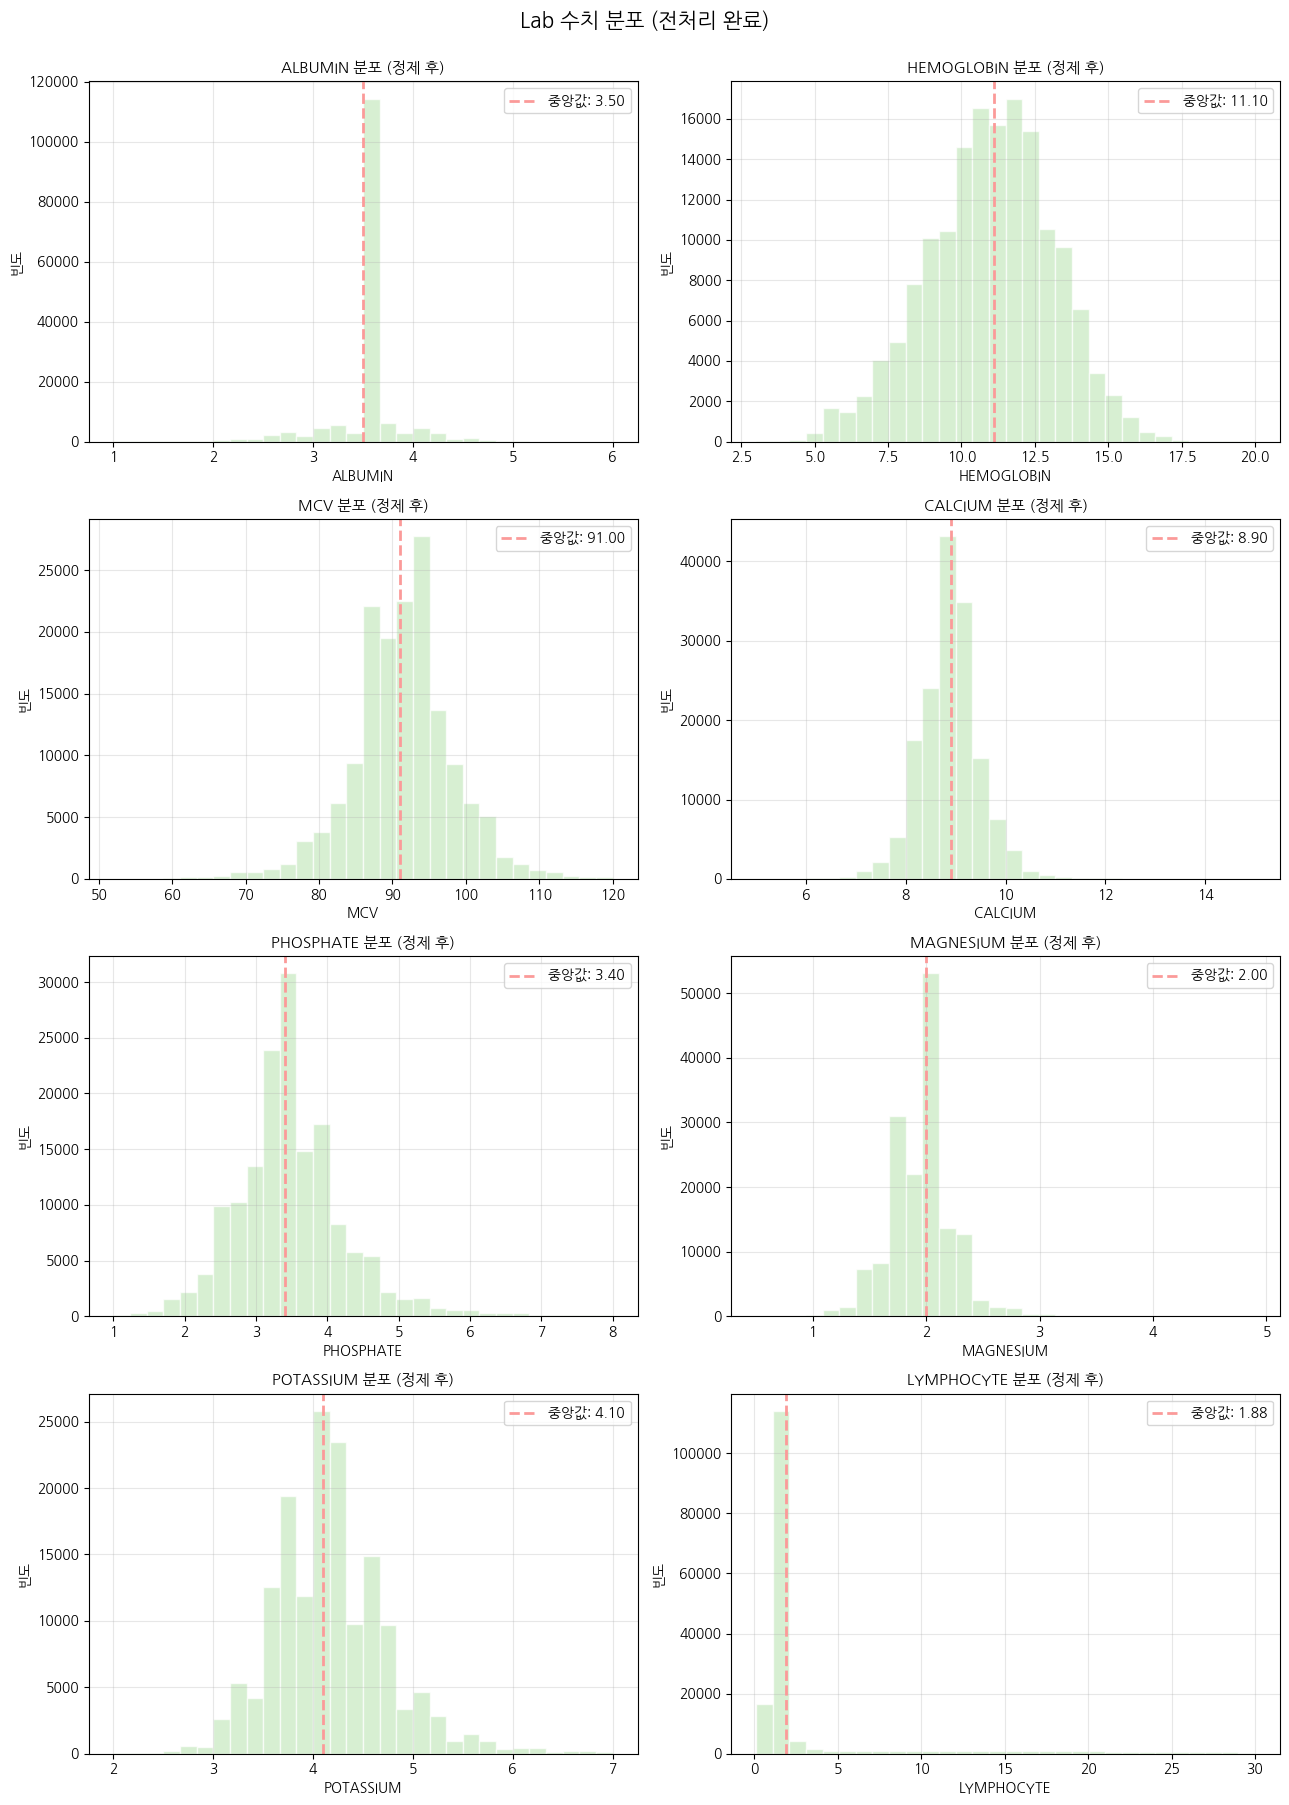

In [ ]:
# ============================================================================
# STEP 5: 최종 검증
# ============================================================================
print("\n" + "="*80)
print("✅ STEP 5: 최종 검증")
print("="*80)

print(f"\n📊 최종 데이터:")
print(f"   - 행: {len(nutrition_cohort):,}개")
print(f"   - 열: {len(nutrition_cohort.columns)}개")
print(f"   - 결측치: {nutrition_cohort.isnull().sum().sum()}개")


# Lab 수치 분포 확인
print(f"\n📊 주요 Lab 수치 통계 (처리 후):")
for var in ['ALBUMIN', 'HEMOGLOBIN', 'CALCIUM', 'POTASSIUM']:
    if var in nutrition_cohort.columns:
        print(f"\n{var}:")
        print(f"   평균: {nutrition_cohort[var].mean():.2f}")
        print(f"   중앙값: {nutrition_cohort[var].median():.2f}")
        print(f"   범위: [{nutrition_cohort[var].min():.2f}, {nutrition_cohort[var].max():.2f}]")

# 최종 시각화
fig, axes = plt.subplots(4, 2, figsize=(13,18))
axes = axes.flatten()

for idx, var in enumerate(lab_vars_available[:8]): # 'lab_vars'를 'lab_vars_available'로 수정
    if var in nutrition_cohort.columns:
        data = nutrition_cohort[var]

        axes[idx].hist(data, bins=30, color=COLORS['success'],
                      edgecolor='white', alpha=0.7)
        axes[idx].axvline(data.median(), color=COLORS['danger'],
                         linestyle='--', linewidth=2, label=f'중앙값: {data.median():.2f}')
        axes[idx].set_xlabel(var, fontweight='bold')
        axes[idx].set_ylabel('빈도', fontweight='bold')
        axes[idx].set_title(f'{var} 분포 (정제 후)', fontsize=11, fontweight='bold')
        axes[idx].legend()
        axes[idx].grid(alpha=0.3)

plt.suptitle('Lab 수치 분포 (전처리 완료)', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# STEP 6: 저장
# ============================================================================
print("\n" + "="*80)
print("💾 STEP 6: 저장")
print("="*80)

output_path = f'{base_path}nutrition_cohort_final.csv'
nutrition_cohort.to_csv(output_path, index=False)
print(f"✅ 저장 완료: {output_path}")


💾 STEP 6: 저장
✅ 저장 완료: /content/drive/MyDrive/ColabNotebooks/nutrition_cohort_final.csv
